## Importaciones y rutas

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Directorio actual donde está este notebook
ruta_base = os.getcwd()

# Si RLCodeBase.py está en la carpeta padre, lo añadimos al path
ruta_padre = os.path.abspath(os.path.join(ruta_base, '..'))
if ruta_padre not in sys.path:
    sys.path.append(ruta_padre)

# Nota: Si en tu RLCodeBase.py existen funciones explícitas para plotear bandas, 
# impórtalas aquí. Por ejemplo: 
# from RLCodeBase import plot_learning_curves_with_tolerance_intervals

## Carga de datos

Cargamos los datos generados al entrenar.

In [2]:
# Definir las rutas a los archivos .npy
ruta_q_matrix = os.path.join(ruta_base, "2_Q-learning", "Resultados_Entrenamiento_Q", "q_learning_costs_matrix.npy")

q_costs = np.load(ruta_q_matrix)

print(f"Datos de Q-Learning cargados. Dimensiones: {q_costs.shape} (Runs, Episodios)")

# ---------------------------------------------------------
# PREPARACIÓN PARA CUANDO TENGAS PPO (Descomentar en el futuro)
# ---------------------------------------------------------
# ruta_ppo_matrix = os.path.join(ruta_base, "PPO", "Resultados_Entrenamiento_PPO", "ppo_costs_matrix.npy")
# ppo_costs = np.load(ruta_ppo_matrix)
# print(f"Datos de PPO cargados. Dimensiones: {ppo_costs.shape}")

Datos de Q-Learning cargados. Dimensiones: (30, 15) (Runs, Episodios)


## Visualización estadística

### Confidence interval

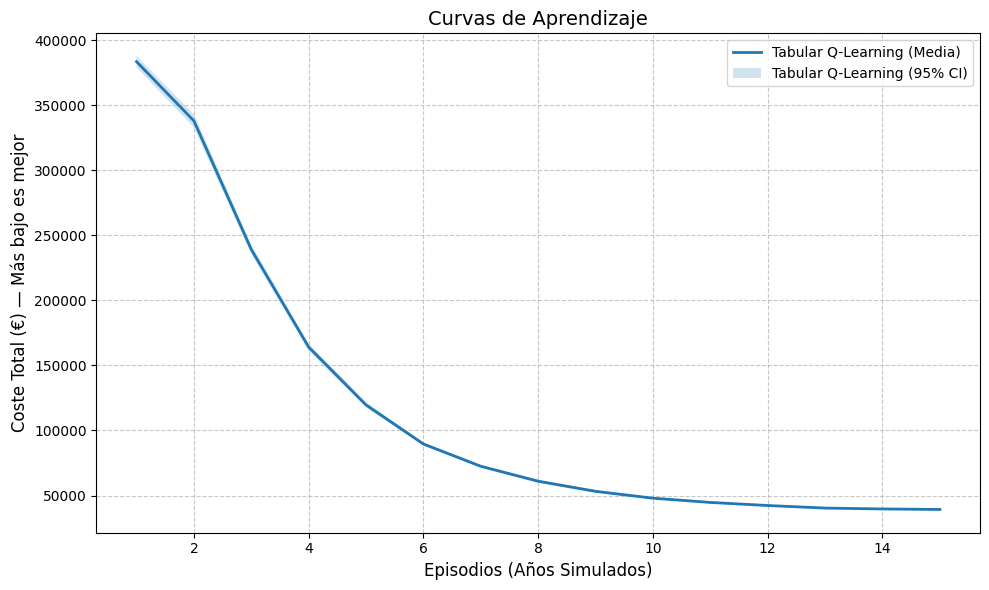

In [3]:
def plot_confidence_interval(data_dict, title="Curvas de Aprendizaje"):
    plt.figure(figsize=(10, 6))
    
    for label, data in data_dict.items():
        n_runs, n_eps = data.shape
        mean_costs = np.mean(data, axis=0)
        std_costs  = np.std(data, axis=0, ddof=1)  # ddof=1 para muestral
        
        # t-distribution (más correcto que Z para muestras finitas)
        t_crit = stats.t.ppf(0.975, df=n_runs - 1)
        ci = t_crit * (std_costs / np.sqrt(n_runs))
        
        episodes = np.arange(1, n_eps + 1)
        plt.plot(episodes, mean_costs, label=f"{label} (Media)", linewidth=2)
        plt.fill_between(episodes, mean_costs - ci, mean_costs + ci,
                         alpha=0.2, label=f"{label} (95% CI)")
    
    plt.title(title, fontsize=14)
    plt.xlabel("Episodios (Años Simulados)", fontsize=12)
    plt.ylabel("Coste Total (€)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig("learning_curve_CI.png", dpi=150)
    plt.show()

plot_confidence_interval({"Tabular Q-Learning": q_costs})

### Tolerance interval

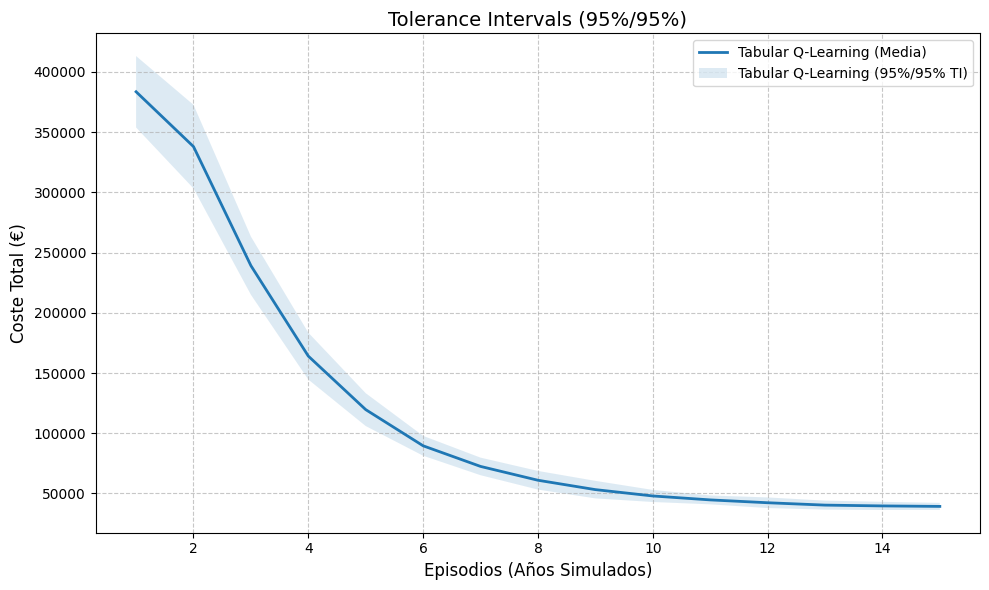

In [4]:
def tolerance_interval_normal(data, coverage=0.95, confidence=0.95):
    """
    Tolerance interval paramétrico (asume normalidad).
    Devuelve (lower, upper) para cada episodio.
    coverage   = proporción de la población a cubrir (β)
    confidence = nivel de confianza del intervalo (1-α)
    """
    n = data.shape[0]
    mean = np.mean(data, axis=0)
    std  = np.std(data, axis=0, ddof=1)
    
    # Factor k de tolerance interval (Wald & Wolfowitz)
    # k = z_beta + sqrt((z_beta^2 - (z_alpha^2/n)) * ... )  — approx de Hahn
    # Usamos la aproximación práctica con chi2:
    z_beta  = stats.norm.ppf((1 + coverage) / 2)      # z para cobertura bilateral
    chi2_val = stats.chi2.ppf(1 - confidence, df=n - 1)
    k = np.sqrt((n - 1) * (1 + 1/n) * z_beta**2 / chi2_val)
    
    return mean - k * std, mean + k * std

def plot_tolerance_interval(data_dict, title="Tolerance Intervals (95%/95%)"):
    plt.figure(figsize=(10, 6))
    
    for label, data in data_dict.items():
        n_eps = data.shape[1]
        mean_costs = np.mean(data, axis=0)
        low_ti, high_ti = tolerance_interval_normal(data)
        
        episodes = np.arange(1, n_eps + 1)
        plt.plot(episodes, mean_costs, label=f"{label} (Media)", linewidth=2)
        plt.fill_between(episodes, low_ti, high_ti, alpha=0.15,
                         label=f"{label} (95%/95% TI)")
    
    plt.title(title, fontsize=14)
    plt.xlabel("Episodios (Años Simulados)", fontsize=12)
    plt.ylabel("Coste Total (€)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig("learning_curve_TI.png", dpi=150)
    plt.show()

plot_tolerance_interval({"Tabular Q-Learning": q_costs})

### Welch T-test

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# 3. WELCH T-TEST  (Q-Learning vs PPO — activa cuando tengas PPO)
# Welch no asume igual varianza → más robusto que Student clásico
# Comparamos el coste del ÚLTIMO episodio (política convergida)
# ══════════════════════════════════════════════════════════════════════════
def welch_ttest(costs_a, costs_b, label_a="Q-Learning", label_b="PPO", 
                episode=-1):
    """
    Compara el coste en un episodio dado (por defecto el último).
    costs_a, costs_b: matrices (runs, episodes)
    """
    sample_a = costs_a[:, episode]  # coste final de cada run
    sample_b = costs_b[:, episode]
    
    t_stat, p_value = stats.ttest_ind(sample_a, sample_b, equal_var=False)
    
    print(f"\n{'='*55}")
    print(f"  Welch t-test: {label_a} vs {label_b} (episodio {episode})")
    print(f"{'='*55}")
    print(f"  {label_a}: media={np.mean(sample_a):.2f}€  std={np.std(sample_a):.2f}€")
    print(f"  {label_b}: media={np.mean(sample_b):.2f}€  std={np.std(sample_b):.2f}€")
    print(f"  t-statistic : {t_stat:.4f}")
    print(f"  p-value     : {p_value:.4f}")
    
    alpha = 0.05
    if p_value < alpha:
        mejor = label_a if np.mean(sample_a) < np.mean(sample_b) else label_b
        print(f"  → Diferencia SIGNIFICATIVA (p<{alpha}). {mejor} es mejor.")
    else:
        print(f"  → No hay diferencia significativa (p≥{alpha}).")
    
    return t_stat, p_value

# Ejemplo de uso (descomenta cuando tengas ppo_costs):
# welch_ttest(q_costs, ppo_costs, "Q-Learning", "PPO")

# Mientras tanto, test de los últimos 3 episodios vs los primeros 3:
print("=== Verificación de convergencia (primeros vs últimos episodios) ===")
welch_ttest(q_costs[:, :3].reshape(-1,1), q_costs[:, -3:].reshape(-1,1),
            "Primeros 3 eps", "Últimos 3 eps", episode=0)

=== Verificación de convergencia (primeros vs últimos episodios) ===

  Welch t-test: Primeros 3 eps vs Últimos 3 eps (episodio 0)
  Primeros 3 eps: media=320264.95€  std=61360.47€
  Últimos 3 eps: media=39763.17€  std=1373.20€
  t-statistic : 43.1155
  p-value     : 0.0000
  → Diferencia SIGNIFICATIVA (p<0.05). Últimos 3 eps es mejor.


(np.float64(43.115478147062376), np.float64(1.8038027235834914e-61))

### Evaluación de distribución

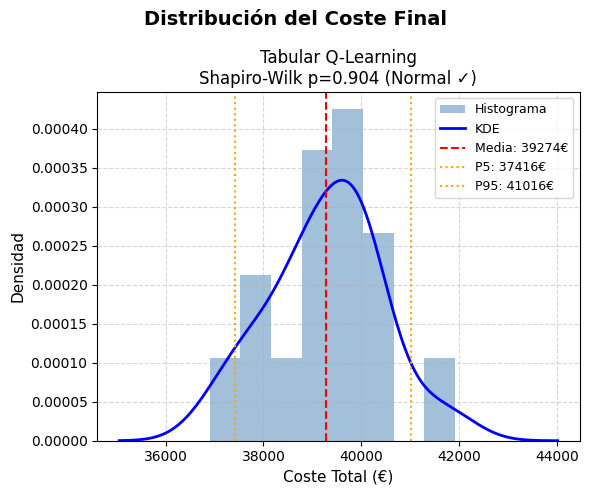

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# 4. EVALUATION DISTRIBUTION  
# Distribución del coste en la política FINAL (último episodio)
# Muestra si el agente es consistente o tiene alta varianza
# ══════════════════════════════════════════════════════════════════════════
def plot_evaluation_distribution(data_dict, episode=-1,
                                  title="Distribución del Coste Final"):
    fig, axes = plt.subplots(1, len(data_dict), 
                              figsize=(6 * len(data_dict), 5), squeeze=False)
    
    for ax, (label, data) in zip(axes[0], data_dict.items()):
        final_costs = data[:, episode]
        
        # Histograma + KDE
        ax.hist(final_costs, bins=8, density=True, alpha=0.5,
                color='steelblue', label='Histograma')
        
        # KDE suavizado
        kde = stats.gaussian_kde(final_costs)
        x_range = np.linspace(final_costs.min() * 0.95, 
                               final_costs.max() * 1.05, 200)
        ax.plot(x_range, kde(x_range), 'b-', linewidth=2, label='KDE')
        
        # Líneas de media y percentiles
        mean_val   = np.mean(final_costs)
        p5, p95    = np.percentile(final_costs, [5, 95])
        
        ax.axvline(mean_val, color='red',    linestyle='--', 
                   linewidth=1.5, label=f'Media: {mean_val:.0f}€')
        ax.axvline(p5,       color='orange', linestyle=':',  
                   linewidth=1.5, label=f'P5: {p5:.0f}€')
        ax.axvline(p95,      color='orange', linestyle=':',  
                   linewidth=1.5, label=f'P95: {p95:.0f}€')
        
        # Test de normalidad Shapiro-Wilk
        stat_sw, p_sw = stats.shapiro(final_costs)
        ax.set_title(f"{label}\nShapiro-Wilk p={p_sw:.3f} "
                     f"({'Normal ✓' if p_sw>0.05 else 'No normal ✗'})",
                     fontsize=12)
        ax.set_xlabel("Coste Total (€)", fontsize=11)
        ax.set_ylabel("Densidad", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("evaluation_distribution.png", dpi=150)
    plt.show()

plot_evaluation_distribution({"Tabular Q-Learning": q_costs})

### Resumen estadístico

In [7]:
# ══════════════════════════════════════════════════════════════════════════
# 5. RESUMEN ESTADÍSTICO COMPLETO (tabla)
# ══════════════════════════════════════════════════════════════════════════
def resumen_estadistico(data_dict, episode=-1):
    print(f"\n{'='*65}")
    print(f"  RESUMEN ESTADÍSTICO — Episodio final")
    print(f"{'='*65}")
    print(f"  {'Algoritmo':<20} {'Media':>10} {'Std':>10} "
          f"{'P5':>10} {'P95':>10} {'Min':>10} {'Max':>10}")
    print(f"  {'-'*65}")
    
    for label, data in data_dict.items():
        final = data[:, episode]
        print(f"  {label:<20} "
              f"{np.mean(final):>10.2f} "
              f"{np.std(final, ddof=1):>10.2f} "
              f"{np.percentile(final, 5):>10.2f} "
              f"{np.percentile(final, 95):>10.2f} "
              f"{np.min(final):>10.2f} "
              f"{np.max(final):>10.2f}")

resumen_estadistico({"Tabular Q-Learning": q_costs})


  RESUMEN ESTADÍSTICO — Episodio final
  Algoritmo                 Media        Std         P5        P95        Min        Max
  -----------------------------------------------------------------
  Tabular Q-Learning     39274.34    1148.35   37416.38   41015.65   36899.01   41911.41
